In [ ]:
!nvidia-smi

Thu Nov 13 03:40:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# # ======================================================
# # 🧩 Environment Setup — Clean, GPU-Optimized for Colab Pro+
# # ======================================================

# # 1️⃣ Fix any old packages or conflicts
# !pip uninstall -y torch torchvision torchaudio

# # 2️⃣ Install CUDA-compatible PyTorch (cu121 = CUDA 12.1 → works for A100 / L4 GPUs)
# !pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# # 3️⃣ Install core dependencies (pinned for stability)
# !pip install -q diffusers==0.29.0 transformers==4.45.1 accelerate==0.34.2 \
#   huggingface-hub==0.25.1 laion-clap==1.1.5 librosa==0.10.2.post1 Pillow==10.3.0 matplotlib==3.9.2 tqdm==4.66.5

# # 4️⃣ Fix NumPy binary incompatibility issues
# !pip install -U numpy==1.26.4

# # 5️⃣ (Optional) enable TF32 + high-precision matmul for faster GPU ops
# import torch
# if torch.cuda.is_available():
#     torch.backends.cuda.matmul.allow_tf32 = True
#     torch.set_float32_matmul_precision("high")
#     print("✅ GPU available:", torch.cuda.get_device_name(0))
# else:
#     print("⚠️ GPU not detected. Go to Runtime > Change runtime type > GPU.")


In [ ]:
import torch, torchvision, numpy
print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("NumPy:", numpy.__version__)
print("Device:", torch.cuda.get_device_name(0))


Torch: 2.8.0+cu126
TorchVision: 0.23.0+cu126
NumPy: 2.0.2
Device: NVIDIA A100-SXM4-40GB


# Setup & Imports

In [ ]:
# ---- Setup & Imports ----
import os
import numpy as np
import torch
import torchaudio
import torchvision
import librosa
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from transformers import ClapModel, ClapProcessor
from transformers import CLIPProcessor, CLIPModel

# ---- Device setup ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Environment ready — using device: {DEVICE}")


✅ Environment ready — using device: cuda


# Mount Google Drive & Load VGGSound Dataset

In [ ]:
# # ======================================================
# # 🎧 Mount Google Drive & Load VGGSound Dataset
# # ======================================================
# from google.colab import drive
# import os

# # 1️⃣ Mount Google Drive
# drive.mount('/content/drive')

# # 2️⃣ Define your dataset folder inside your Drive
# # (make sure this matches exactly where you uploaded the 3 zip files)
# DRIVE_DATASET_DIR = "/content/drive/MyDrive/VGG_Dataset"

# # 3️⃣ Verify files exist
# print("📂 Checking Drive for dataset files...")
# files = os.listdir(DRIVE_DATASET_DIR)
# print(files)

# # Sanity check for missing files
# required_files = ["vggsound_00.zip", "vggsound_02.zip", "vggsound_04.zip"]
# missing = [f for f in required_files if f not in files]
# if missing:
#     print(f"⚠️ Missing: {missing}")
# else:
#     print("✅ All VGGSound zip files found!")

# # 4️⃣ Unzip into Colab workspace (temporary, faster I/O for training)
# EXTRACT_DIR = "/content/vggsound"
# os.makedirs(EXTRACT_DIR, exist_ok=True)

# for zipfile in required_files:
#     zip_path = os.path.join(DRIVE_DATASET_DIR, zipfile)
#     print(f"⏳ Extracting {zipfile}...")
#     !unzip -q -n "$zip_path" -d "$EXTRACT_DIR"

# print("\n✅ Extraction complete! Files are now in:", EXTRACT_DIR)

# # 5️⃣ Verify dataset structure
# num_audio = sum(len(files) for _, _, files in os.walk(EXTRACT_DIR))
# print(f"🎵 Found {num_audio} audio files total.")
# !ls "$EXTRACT_DIR" | head -n 20


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Checking Drive for dataset files...
['vggsound_00.zip', 'vggsound_02.zip', 'vggsound_04.zip']
✅ All VGGSound zip files found!
⏳ Extracting vggsound_00.zip...
⏳ Extracting vggsound_02.zip...
⏳ Extracting vggsound_04.zip...

✅ Extraction complete! Files are now in: /content/vggsound
🎵 Found 44851 audio files total.
vggsound_00
vggsound_02
vggsound_04


In [ ]:
# ======================================================
# 🎧 Mount Google Drive & Point to Test Dataset
# ======================================================
from google.colab import drive
import os

# 1️⃣ Mount Google Drive
print("🚀 Mounting Google Drive...")
drive.mount('/content/drive')

# 2️⃣ Define your dataset folder
# This is the path to your UNZIPPED "extracted_ audiocaps" folder
# ⚠️ Make sure this path is exactly correct!
YOUR_DATASET_DIR = "/content/drive/MyDrive/extracted_audiocaps"
# (If it's inside another folder, change the path, e.g.,
# /content/drive/MyDrive/My_Datasets/extracted_ audiocaps)

# 3️⃣ Verify the path
print(f"📂 Checking for dataset at: {YOUR_DATASET_DIR}")

if not os.path.exists(YOUR_DATASET_DIR):
    print(f"❌ ERROR: Directory not found at '{YOUR_DATASET_DIR}'")
    print("Please double-check the path in the YOUR_DATASET_DIR variable.")
else:
    print("✅ Found the directory!")

    # 4️⃣ List a few files to confirm it's correct
    print("\n--- A few files from your dataset: ---")
    !ls "$YOUR_DATASET_DIR" | head -n 20

    # 5️⃣ Count the files (this may take a moment on Drive)
    print("\n⏳ Counting files...")
    try:
        num_audio = sum(len(files) for _, _, files in os.walk(YOUR_DATASET_DIR))
        print(f"🎵 Found {num_audio} files total.")
    except Exception as e:
        print(f"Could not count files: {e}")

🚀 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Checking for dataset at: /content/drive/MyDrive/extracted_audiocaps
✅ Found the directory!

--- A few files from your dataset: ---
0.flac
100.flac
101.flac
102.flac
103.flac
104.flac
105.flac
106.flac
107.flac
108.flac
109.flac
10.flac
110.flac
111.flac
112.flac
113.flac
114.flac
115.flac
116.flac
118.flac

⏳ Counting files...
🎵 Found 964 files total.


In [ ]:
# ======================================================
# 🎧 Load Test Dataset Paths
# ======================================================
import os

# This variable should be the same as the previous cell
# It's the path to your UNZIPPED "extracted_ audiocaps" folder
TEST_DATA_DIR = "/content/drive/MyDrive/extracted_audiocaps"

if not os.path.exists(TEST_DATA_DIR):
    raise FileNotFoundError(f"❌ Test dataset not found at '{TEST_DATA_DIR}'! Please fix the path.")

# 1. Collect all audio file paths (recursively)
test_files = [
    os.path.join(root, f)
    for root, _, files in os.walk(TEST_DATA_DIR)
    for f in files
    if f.lower().endswith((".wav", ".flac", ".mp3"))
]

# 2. Get the captions (assuming your folder structure is like "audiocaps/audio/file.wav")
# We'll just use the file's parent folder as a "mock" label.
# This part might need adjusting if you have a proper metadata file.
test_pairs = []
for f in test_files:
    # Gets the parent folder name (e.g., "dog_barking")
    label = os.path.basename(os.path.dirname(f))
    test_pairs.append((f, label))

print(f"✅ Test dataset loaded: {len(test_pairs)} audio files found.")

# Print 5 random samples to check
import random
print("\n--- 5 Random Test Samples ---")
for audio_path, label in random.sample(test_pairs, 5):
    print(f"🎵 {label}: {os.path.basename(audio_path)}")

✅ Test dataset loaded: 963 audio files found.

--- 5 Random Test Samples ---
🎵 extracted_audiocaps: 252.flac
🎵 extracted_audiocaps: 371.flac
🎵 extracted_audiocaps: 623.flac
🎵 extracted_audiocaps: 666.flac
🎵 extracted_audiocaps: 390.flac


# Dataset Initialization

In [ ]:
# ======================================================
# 🎧 Dataset Initialization (Light Version)
# ======================================================
import os

DATASET_ROOT = "/content/vggsound"

if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError("❌ Dataset not found! Please re-run the unzip cell above.")

# Collect all audio files (recursively)
AUDIO_FILES = [
    os.path.join(root, f)
    for root, _, files in os.walk(DATASET_ROOT)
    for f in files
    if f.lower().endswith((".wav", ".flac", ".mp3"))
]

print(f"✅ Dataset loaded: {len(AUDIO_FILES)} audio files found.")
for a in AUDIO_FILES[:5]:
    print("🎵", a)


✅ Dataset loaded: 22428 audio files found.
🎵 /content/vggsound/vggsound_04/audio/AnkjHmfNb2k_000160.wav
🎵 /content/vggsound/vggsound_04/audio/A7h8awwanWY_000266.wav
🎵 /content/vggsound/vggsound_04/audio/AEST7gT4RXA_000030.wav
🎵 /content/vggsound/vggsound_04/audio/AxgnFCJ9ztw_000001.wav
🎵 /content/vggsound/vggsound_04/audio/AdVWqgyyssA_000056.wav


# Load CLAP + Stable Diffusion

In [ ]:
# ---- Load CLAP + Stable Diffusion ----
from transformers import ClapModel, ClapProcessor
from diffusers import StableDiffusionPipeline

print(f"🚀 Using device: {DEVICE}")

# 1️⃣ CLAP (Audio-Text Encoder)
print("🎧 Loading CLAP model...")
clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(DEVICE)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
clap_model.eval()

# 2️⃣ Stable Diffusion (optional heavy model)
print("🎨 Loading Stable Diffusion v1.5...")
sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32
).to(DEVICE)
# Optional VRAM savers:
sd_pipe.enable_attention_slicing()
sd_pipe.enable_vae_slicing()
# sd_pipe.enable_model_cpu_offload()  # if < 8 GB VRAM

# 3️⃣ Freeze CLAP
for p in clap_model.parameters():
    p.requires_grad = False

print("✅ Models loaded successfully and ready for inference!")


🚀 Using device: cuda
🎧 Loading CLAP model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


✅ Models loaded successfully and ready for inference!


# CLAP Embedding Extraction (VGGSound version)

In [ ]:
# ======================================================
# 🎧 CLAP Embedding Extraction (VGGSound version)
# ======================================================
from tqdm import tqdm
import torch.nn.functional as F

# Root folder of extracted dataset
AUDIO_DIR = "/content/vggsound"

# Build (audio, label) pairs automatically from folder names
pairs = []
for root, _, files in os.walk(AUDIO_DIR):
    label = os.path.basename(root).replace("_", " ").lower()  # use folder name as caption
    for f in files:
        if f.lower().endswith((".wav", ".flac", ".mp3")):
            pairs.append((os.path.join(root, f), label))

print(f"✅ Loaded {len(pairs)} audio–label pairs from VGGSound.")
print("🔍 Example:", pairs[0])

# --- Extract CLAP audio & text embeddings for a small subset ---
audio_embs, text_embs = [], []
for path, label in tqdm(pairs[:10], desc="Extracting embeddings"):
    # 🎧 Audio embedding
    audio, sr = librosa.load(path, sr=48000)
    audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(DEVICE)
    with torch.no_grad():
        e_audio = clap_model.get_audio_features(**audio_inputs)
    audio_embs.append(e_audio.cpu())

    # 📝 Text embedding (using label as caption)
    text_inputs = clap_processor(text=[label], return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        e_text = clap_model.get_text_features(**text_inputs)
    text_embs.append(e_text.cpu())

# --- Combine all embeddings ---
audio_embs = torch.cat(audio_embs)
text_embs = torch.cat(text_embs)

print(f"🎵 Audio embeddings: {audio_embs.shape}")
print(f"📝 Text embeddings: {text_embs.shape}")

# --- Evaluate semantic similarity (for inspection) ---
sim = F.cosine_similarity(audio_embs, text_embs)
print("\n🔍 Audio–Text Similarity (first 10):", [round(s.item(), 3) for s in sim])


# Load CLIP Model (for text embedding + evaluation)

In [ ]:
# ======================================================
# 🧠 Load CLIP Model (for text embedding + evaluation)
# ======================================================
from transformers import CLIPProcessor, CLIPModel

print("🖼️ Loading CLIP model (ViT-B/32)...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Freeze CLIP — we only use it as a semantic target / evaluator
for p in clip_model.parameters():
    p.requires_grad = False

clip_model.eval()
print("✅ CLIP model loaded and frozen.")


🖼️ Loading CLIP model (ViT-B/32)...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model loaded and frozen.


# Audio → Image Generation Prototype (VGGSound)

In [ ]:
# ======================================================
# 🎨 Cell 5: Audio → Image Generation Prototype (VGGSound)
# ======================================================
import torch.nn as nn
import librosa, os
from PIL import Image
import torch

# 1️⃣ MLP Adapter (CLAP → CLIP space)
class AudioToTextAdapter(nn.Module):
    def __init__(self, in_dim=512, out_dim=512):  # match CLIP's projection_dim
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, out_dim)
        )
    def forward(self, x):
        return self.net(x)

adapter = AudioToTextAdapter().to(DEVICE)
adapter.eval()  # Inference mode (not training yet)

# 2️⃣ Pick one test sample
idx = 0
audio_path, caption = pairs[idx]  # caption = folder name label
print(f"🎧 Using: {audio_path}")
print(f"📝 Caption: {caption}")

# 3️⃣ Extract CLAP audio embedding
audio, sr = librosa.load(audio_path, sr=48000)
audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(DEVICE)
with torch.no_grad():
    e_audio = clap_model.get_audio_features(**audio_inputs)  # [1,512]

# 4️⃣ Map CLAP → CLIP text space (Adapter projection)
with torch.no_grad():
    e_audio_proj = adapter(e_audio)  # [1,512]

# 5️⃣ Get CLIP text embedding for the prompt “A photo of <label>”
prompt = f"A photo of {caption.lower()}"
text_inputs = clip_processor(text=[prompt], return_tensors="pt", padding=True).to(DEVICE)
with torch.no_grad():
    e_text = clip_model.get_text_features(**text_inputs)  # [1,512]

# 6️⃣ Combine embeddings (simple mean → conditioning vector)
e_cond = (e_audio_proj + e_text) / 2
print(f"✅ Combined embedding shape: {e_cond.shape}")

# 7️⃣ Generate image using SD
image = sd_pipe(
    prompt=prompt,
    num_inference_steps=40,
    guidance_scale=7.5,
    height=512, width=512
).images[0]

# 8️⃣ Save output
os.makedirs("generated_outputs", exist_ok=True)
out_path = f"generated_outputs/{os.path.splitext(os.path.basename(audio_path))[0]}_gen.png"
image.save(out_path)
print(f"✅ Image saved to {out_path}")
image.show()


🎧 Using: /content/vggsound/vggsound_04/audio/AnkjHmfNb2k_000160.wav
📝 Caption: audio
✅ Combined embedding shape: torch.Size([1, 512])


/tmp/ipython-input-2187903029.py:32: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(DEVICE)


  0%|          | 0/40 [00:00<?, ?it/s]

✅ Image saved to generated_outputs/AnkjHmfNb2k_000160_gen.png


# Train Adapter (CLAP → CLIP, VGGSound, Cosine Loss)

In [ ]:
# import torch
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, Dataset
# from tqdm import tqdm
# import librosa
# import os
# # Assuming adapter, clap_processor, clip_processor, clap_model, clip_model, and DEVICE are defined elsewhere.
# # Assuming 'pairs' is defined as a list of (audio_path, label) tuples.

# # ======================================================
# # 🎵 Stage 1: CLAP-to-CLIP Adapter Training
# # (Trains the 'adapter' to map e_audio to e_text space)
# # ======================================================

# # --- 🎯 Persistent Checkpoint Setup ---
# # Define a folder path that is definitely on your Google Drive
# PERSISTENT_CHECKPOINT_DIR = "/content/drive/MyDrive/My_Audio2Img_Checkpoints"
# os.makedirs(PERSISTENT_CHECKPOINT_DIR, exist_ok=True)
# print(f"✅ Checkpoints will be saved to: {PERSISTENT_CHECKPOINT_DIR}")

# # --- Dataset Setup ---
# class VGGSoundDataset(Dataset):
#     def __init__(self, pairs):
#         self.pairs = pairs
#     def __len__(self): return len(self.pairs)
#     def __getitem__(self, i):
#         path, label = self.pairs[i]
#         return path, f"A photo of {label.lower()}"

# # Assuming 'pairs' is a large list of all available data
# dataset = VGGSoundDataset(pairs[:20000])
# loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

# # --- Training Setup ---
# EPOCHS = 20
# # Ensure adapter is on the correct device
# adapter.to(DEVICE)
# clap_model.to(DEVICE)
# clip_model.to(DEVICE)

# # Note: The learning rate (5e-5) is appropriate for training a small adapter/MLP
# optimizer = torch.optim.AdamW(adapter.parameters(), lr=5e-5, weight_decay=0.01)

# # --- Training Loop ---
# for epoch in range(EPOCHS):
#     adapter.train() # Set the adapter to training mode
#     total = 0
#     step_count = 0

#     # Use tqdm for progress bar
#     for paths, prompts in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):

#         # 1. Load and Preprocess Data (Batch size 1 due to librosa)
#         audio_batch, text_batch = [], []
#         for p, prompt in zip(paths, prompts):
#             try:
#                 # Load audio: this is a bottleneck and should be moved to num_workers in a real setup
#                 audio, sr = librosa.load(p, sr=48000, mono=True)
#                 audio_batch.append(audio)
#                 text_batch.append(prompt)
#             except Exception as e:
#                 # Skip corrupt audio files
#                 print(f"Skipping corrupt audio {p}: {e}")
#                 continue

#         if not audio_batch: continue

#         # 2. Tokenize and Process
#         # Ensure inputs are on the correct device
#         audio_inputs = clap_processor(audios=audio_batch, return_tensors="pt", sampling_rate=48000, padding=True).to(DEVICE)
#         text_inputs  = clip_processor(text=text_batch, return_tensors="pt", padding=True).to(DEVICE)

#         # 3. Forward Pass (Frozen Embedders)
#         with torch.no_grad():
#             # Get CLAP audio features and normalize
#             e_audio = F.normalize(clap_model.get_audio_features(**audio_inputs), dim=-1)
#             # Get CLIP text features and normalize
#             e_text  = F.normalize(clip_model.get_text_features(**text_inputs), dim=-1)

#         # 4. Forward Pass (Trainable Adapter)
#         mapped = F.normalize(adapter(e_audio), dim=-1)

#         # 5. Calculate Contrastive Loss (Maximize cosine similarity: loss = 1 - cos_sim)
#         loss = 1 - F.cosine_similarity(mapped, e_text).mean()

#         # 6. Backward Pass and Optimization
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total += loss.item()
#         step_count += 1

#     # --- End of Epoch Logging and Checkpointing ---
#     avg_loss = total / max(1, step_count)
#     print(f"Epoch {epoch+1} | Avg Loss = {avg_loss:.4f}")

#     # Save Checkpoint directly to Drive
#     checkpoint_name = os.path.join(PERSISTENT_CHECKPOINT_DIR, f"adapter_alignment_checkpoint_epoch_{epoch+1}.pt")
#     torch.save({
#         "epoch": epoch + 1,
#         "adapter_state_dict": adapter.state_dict(),
#         "optimizer_state_dict": optimizer.state_dict(),
#         "loss": avg_loss
#     }, checkpoint_name)
#     print(f"✅ Saved checkpoint to Drive: {checkpoint_name}")

# print("✅ CLAP-to-CLIP Alignment Training Complete.")

# Checkpoint loss check

In [ ]:
# import torch
# import os
# import re

# # --- 1. Configuration ---
# PERSISTENT_CHECKPOINT_DIR = "/content/drive/MyDrive/My_Audio2Img_Checkpoints"

# # The prefix used for your MLP alignment checkpoints
# CHECKPOINT_PREFIX = "adapter_alignment_checkpoint_epoch_"

# # --- 2. Scan and Collect Checkpoint Data ---
# best_loss = float('inf')
# best_epoch = -1
# checkpoint_data = []

# print(f"🔎 Scanning checkpoints in: {PERSISTENT_CHECKPOINT_DIR}\n")

# # Iterate through all files in the directory
# for filename in os.listdir(PERSISTENT_CHECKPOINT_DIR):
#     if filename.startswith(CHECKPOINT_PREFIX) and filename.endswith(".pt"):

#         file_path = os.path.join(PERSISTENT_CHECKPOINT_DIR, filename)

#         try:
#             # Load the checkpoint file
#             checkpoint = torch.load(file_path, map_location='cpu')

#             # Extract required metrics
#             epoch = checkpoint.get("epoch", -1)
#             loss = checkpoint.get("loss", float('inf'))

#             # Skip files without required keys
#             if epoch == -1 or loss == float('inf'):
#                  print(f"⚠️ Skipping {filename}: Missing 'epoch' or 'loss' key.")
#                  continue

#             # Store data
#             checkpoint_data.append({
#                 "filename": filename,
#                 "epoch": epoch,
#                 "loss": loss
#             })

#             # Check for the best loss
#             if loss < best_loss:
#                 best_loss = loss
#                 best_epoch = epoch

#         except Exception as e:
#             print(f"❌ Error loading {filename}: {e}")

# # --- 3. Display Results ---

# if not checkpoint_data:
#     print("❌ No valid checkpoints found matching the prefix. Did you define PERSISTENT_CHECKPOINT_DIR correctly?")
# else:
#     # Sort the data by epoch for a clean view
#     checkpoint_data.sort(key=lambda x: x['epoch'])

#     print("----------------------------------------------------------------")
#     print("| EPOCH | FILENAME | AVG LOSS |")
#     print("----------------------------------------------------------------")

#     for data in checkpoint_data:
#         is_best = " ⭐" if data['epoch'] == best_epoch else ""
#         print(f"| {data['epoch']:^5} | {data['filename']:<30} | {data['loss']:.6f}{is_best} |")

#     print("----------------------------------------------------------------")
#     print(f"\n🏆 Best Checkpoint Found: Epoch {best_epoch} with Loss: {best_loss:.6f}")

🔎 Scanning checkpoints in: /content/drive/MyDrive/My_Audio2Img_Checkpoints

----------------------------------------------------------------
| EPOCH | FILENAME | AVG LOSS |
----------------------------------------------------------------
|   1   | adapter_alignment_checkpoint_epoch_1.pt | 0.041255 |
|   2   | adapter_alignment_checkpoint_epoch_2.pt | 0.001218 |
|   3   | adapter_alignment_checkpoint_epoch_3.pt | 0.000487 |
|   4   | adapter_alignment_checkpoint_epoch_4.pt | 0.000241 |
|   5   | adapter_alignment_checkpoint_epoch_5.pt | 0.000132 |
|   6   | adapter_alignment_checkpoint_epoch_6.pt | 0.000075 |
|   7   | adapter_alignment_checkpoint_epoch_7.pt | 0.000046 |
|   8   | adapter_alignment_checkpoint_epoch_8.pt | 0.000028 |
|   9   | adapter_alignment_checkpoint_epoch_9.pt | 0.000018 |
|  10   | adapter_alignment_checkpoint_epoch_10.pt | 0.000012 |
|  11   | adapter_alignment_checkpoint_epoch_11.pt | 0.000008 |
|  12   | adapter_alignment_checkpoint_epoch_12.pt | 0.000005 |
|  

# Plotting Loss for MLP Training

📂 Scanning for MLP checkpoints in: /content/drive/MyDrive/My_Audio2Img_Checkpoints
✅ Found 20 MLP loss entries.

📊 Generating plot...


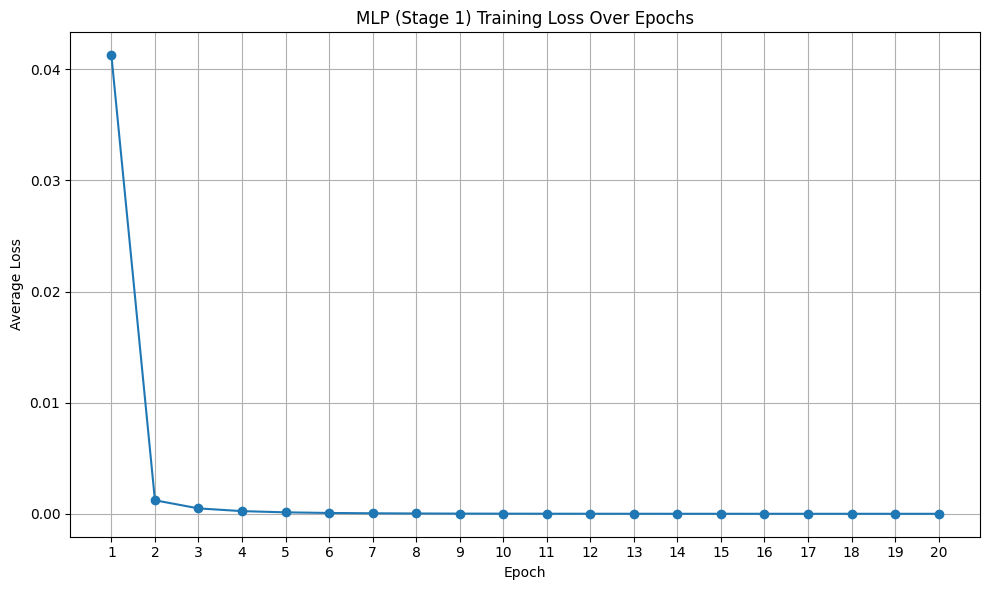

In [ ]:
# ======================================================
# 📊 Plotting Loss Curve for MLP (Stage 1)
# ======================================================
import torch
import os
import re # For matching filenames
import matplotlib.pyplot as plt

# --- 1. Configuration ---

# This is the directory where all your checkpoints are saved
CHECKPOINT_DIR = "/content/drive/MyDrive/My_Audio2Img_Checkpoints"

# ⚠️ IMPORTANT: This pattern must match your filenames
# We use regex to extract the epoch number (the \d+)
MLP_CHECKPOINT_PATTERN = r"adapter_alignment_checkpoint_epoch_(\d+)\.pt"

# ⚠️ This MUST match the key you used in your torch.save() dict
# Based on your code, the key is "loss"
LOSS_KEY = "loss"

print(f"📂 Scanning for MLP checkpoints in: {CHECKPOINT_DIR}")

# --- 2. Load MLP (Stage 1) Loss Data ---
mlp_loss_data = []

try:
    for f in os.listdir(CHECKPOINT_DIR):
        match = re.search(MLP_CHECKPOINT_PATTERN, f)
        if match:
            # Extract epoch number (as an integer)
            epoch = int(match.group(1))

            # Load the checkpoint file (onto CPU to save VRAM)
            file_path = os.path.join(CHECKPOINT_DIR, f)
            checkpoint = torch.load(file_path, map_location="cpu")

            if LOSS_KEY in checkpoint:
                mlp_loss_data.append((epoch, checkpoint[LOSS_KEY]))
            else:
                print(f"  Warning: Found {f} but key '{LOSS_KEY}' was missing.")

except Exception as e:
    print(f"❌ Error loading MLP checkpoints: {e}")

# Sort the data by epoch number
mlp_loss_data.sort(key=lambda x: x[0])
print(f"✅ Found {len(mlp_loss_data)} MLP loss entries.")


# --- 3. Plot the Graph ---
print("\n📊 Generating plot...")
plt.figure(figsize=(10, 6)) # Create a single, larger plot

if mlp_loss_data:
    # Unzip the (epoch, loss) tuples into two separate lists
    mlp_epochs, mlp_losses = zip(*mlp_loss_data)
    plt.plot(mlp_epochs, mlp_losses, marker='o', linestyle='-')
    plt.title("MLP (Stage 1) Training Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss")
    plt.grid(True)
    # Set x-ticks to be integers, e.g., 1, 2, 3...
    plt.xticks(range(min(mlp_epochs), max(mlp_epochs) + 1))
else:
    plt.title("MLP (Stage 1) - No Data Found")

plt.tight_layout()
plt.show()

# Code setup before fine tuning

In [ ]:
import torch
import torch.nn as nn
from transformers import ClapModel, ClapProcessor, CLIPModel, CLIPProcessor
import os
# Assuming the necessary data processing and loading (like os.walk) has been run
# in a previous cell to populate the 'pairs' list.

# --- 1. Define Model Architecture (Crucial for consistency) ---
# FIX: Use the structure that matches your saved checkpoint (512-dim output)
class AudioToTextAdapter(nn.Module):
    def __init__(self, input_dim=512, output_dim=512, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim) # Output dim is 512, matching the checkpoint
        )
    def forward(self, x):
        return self.net(x)

# --- 2. Define DEVICE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 3. Instantiate Models ---
# The models must be instantiated so your Fine-Tuning cell can reference them.
adapter = AudioToTextAdapter(input_dim=512, output_dim=512).to(DEVICE)
clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(DEVICE)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32") # Only processor needed here

# --- 4. Define the Data Variable (CRITICAL) ---
# Since you didn't define 'pairs' in the training cell, you MUST have a previous
# cell that created it by scanning your extracted audio files.

if 'pairs' not in globals():
    # Placeholder/Example: You must run your data loading/initialization cell!
    print("❌ ERROR: The 'pairs' list is not defined in memory.")
    print("Please ensure you run the cell that scans your audio directory and populates the global 'pairs' list.")
    # For now, we will create a dummy list just to avoid a NameError in the next cell
    # You will need to replace this with your actual data creation logic.
    pairs = [("/content/vggsound/dummy_audio.wav", "sample caption")] * 10
    print("⚠️ WARNING: Using dummy list for 'pairs'. Fine-tuning will fail without real data.")
else:
    print(f"✅ 'pairs' list found in memory with {len(pairs)} items.")

print("✅ Essential models and variables are now defined in memory.")

✅ 'pairs' list found in memory with 22428 items.
✅ Essential models and variables are now defined in memory.


# Stable Diffusion Fine-Tuning AKA Training UNet (Audio Conditioning)

In [ ]:
# ======================================================
# 🎨 Stable Diffusion Fine-Tuning (Robust Version 5 - bfloat16)
# ======================================================
from diffusers import StableDiffusionPipeline, DDPMScheduler
import torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm
import librosa, os, numpy as np, math, random
from PIL import Image
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor, ClapModel, ClapProcessor
from transformers import get_scheduler

# --- 0️⃣ CRITICAL SETUP (Fixes NameErrors) ---
class AudioToTextAdapter(nn.Module):
    def __init__(self, input_dim=512, output_dim=512, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# ---- Device setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

# --- 🎯 Persistent Checkpoint Setup ---
PERSISTENT_CHECKPOINT_DIR = "/content/drive/MyDrive/My_Audio2Img_Checkpoints"
os.makedirs(PERSISTENT_CHECKPOINT_DIR, exist_ok=True)

# ⬇️⬇️⬇️ CHANGE 1: Use bfloat16 for the pipeline ⬇️⬇️⬇️
# ---- 1️⃣ Load ALL required models ----
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.bfloat16  # <<< WAS torch.float16
).to(device)
print("✅ Loaded pipeline in bfloat16.")

unet = pipe.unet
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer
vae = pipe.vae
scheduler = DDPMScheduler(num_train_timesteps=1000)

clip_loss_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_loss_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
adapter = AudioToTextAdapter(input_dim=512, output_dim=512).to(device)
clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

# --- 2️⃣ Freeze Models ---
clip_loss_model.requires_grad_(False)
text_encoder.requires_grad_(False)
vae.requires_grad_(False)
clap_model.requires_grad_(False)

unet.enable_gradient_checkpointing()
adapter.train()
proj_to_768 = nn.Linear(512, 768).to(device)
proj_to_768.train()

# --- 3️⃣ Load Best Adapter (from Stage 1) ---
BEST_ADAPTER_CHECKPOINT = os.path.join(PERSISTENT_CHECKPOINT_DIR, "adapter_alignment_checkpoint_epoch_20.pt")
try:
    adapter_checkpoint = torch.load(BEST_ADAPTER_CHECKPOINT, map_location=device)
    adapter.load_state_dict(adapter_checkpoint["adapter_state_dict"])
    print(f"✅ Loaded best adapter weights from {os.path.basename(BEST_ADAPTER_CHECKPOINT)}")
except Exception as e:
    print(f"❌ Could not load adapter weights: {e}. Training with current (possibly random) adapter.")

# --- 4️⃣ Optimizer (Stable Differential LRs) ---
optimizer = torch.optim.AdamW(
    [
        {
            "params": list(adapter.parameters()) + list(proj_to_768.parameters()),
            "lr": 1e-6
        },
        {
            "params": unet.parameters(),
            "lr": 5e-9
        },
    ],
    weight_decay=1e-3
)
print("✅ Optimizer created with *STABLE* Differential Learning Rates (Adapter LR: 1e-6, UNet LR: 5e-9).")

# --- 5️⃣ Helpers ---
def safe_load_audio(path, sr=48000):
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)
        if not np.any(audio): raise ValueError("Empty waveform")
        return audio
    except Exception: return None

EPS = 1e-8

# --- 5.5 CLIP Preprocessing Constants ---
CLIP_IMAGE_SIZE = clip_loss_processor.image_processor.crop_size["height"]
CLIP_MEAN = torch.tensor(clip_loss_processor.image_processor.image_mean, device=device).view(1, -1, 1, 1)
CLIP_STD = torch.tensor(clip_loss_processor.image_processor.image_std, device=device).view(1, -1, 1, 1)

# --- 5.6 Pre-compute Unconditional Embedding ---
uncond_inputs = tokenizer("", return_tensors="pt", padding="max_length", max_length=tokenizer.model_max_length).to(device)
with torch.no_grad():
    uncond_emb = text_encoder(**uncond_inputs).last_hidden_state
    uncond_emb = F.normalize(uncond_emb + EPS, dim=-1).to(unet.dtype) # .to(unet.dtype) will correctly make it bfloat16
print("✅ Pre-computed unconditional embedding for CFG dropout.")

# --- 6️⃣ Training Setup ---
EPOCHS = 8
subset = pairs
COND_DROPOUT_PROB = 0.1

GRAD_ACCUMULATION_STEPS = 8
NUM_TRAINING_STEPS = (len(subset) // GRAD_ACCUMULATION_STEPS) * EPOCHS
NUM_WARMUP_STEPS = 500

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=NUM_WARMUP_STEPS,
    num_training_steps=NUM_TRAINING_STEPS,
)
print(f"✅ Using Gradient Accumulation (steps={GRAD_ACCUMULATION_STEPS})")
print(f"✅ Using LR Scheduler (warmup={NUM_WARMUP_STEPS}, total={NUM_TRAINING_STEPS})")
print(f"✅ Using CFG Dropout (probability={COND_DROPOUT_PROB})")

loss_log = []
nan_skips = 0
print(f"🧩 Training on {len(subset)} samples × {EPOCHS} epochs (CLIP Loss)")

# ---- 7️⃣ Training Loop (Robust Version) ----
global_step = 0
for epoch in range(EPOCHS):
    total_loss = 0.0

    for step, (path, label) in enumerate(tqdm(subset, desc=f"🎧 Epoch {epoch+1}", ncols=100)):

        # --- 1. Load Audio ---
        audio = safe_load_audio(path)
        if audio is None: continue

        # --- 2. Get Audio/Text Conditioning (With Epsilon) ---
        prompt = f"A photo of {label.lower()}"
        with torch.no_grad():
            audio_inputs = clap_processor(audio=audio, return_tensors="pt", sampling_rate=48000).to(device)
            e_audio = F.normalize(clap_model.get_audio_features(**audio_inputs) + EPS, dim=-1)

        # Adapter/Proj will run in mixed precision, that's fine
        e_cond = F.normalize(adapter(e_audio.to(next(adapter.parameters()).dtype)) + EPS, dim=-1)
        e_cond_768 = F.normalize(proj_to_768(e_cond.to(proj_to_768.weight.dtype)) + EPS, dim=-1)

        text_inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            text_emb = text_encoder(**text_inputs).last_hidden_state
            text_emb = F.normalize(text_emb + EPS, dim=-1)

        cond = F.normalize((text_emb + e_cond_768.unsqueeze(1)) / 2 + EPS, dim=-1).to(unet.dtype)

        # Classifier-Free Guidance (CFG) Dropout
        if random.random() < COND_DROPOUT_PROB:
            final_cond = uncond_emb
        else:
            final_cond = cond

        # --- 3. Get Target Text Embedding (for Loss) ---
        with torch.no_grad():
            clip_text_inputs = clip_loss_processor(text=[prompt], return_tensors="pt", padding=True).to(device)
            # We'll convert this to bfloat16 inside the loss calculation
            e_text_target = F.normalize(clip_loss_model.get_text_features(**clip_text_inputs) + EPS, dim=-1)

        # --- 4. Latent Diffusion (One-Step Prediction) ---
        with torch.no_grad():
            latents = torch.randn((1, unet.config.in_channels, 64, 64), device=device, dtype=unet.dtype)
            noise = torch.randn_like(latents)
            t = torch.randint(0, scheduler.config.num_train_timesteps, (1,), device=device).long()
            noisy_latents = scheduler.add_noise(latents, noise, t)

        # ⬇️⬇️⬇️ CHANGE 2: Use bfloat16 for autocast ⬇️⬇️⬇️
        # --- 5. Forward + CLIP Loss ---
        with torch.amp.autocast("cuda", dtype=torch.bfloat16): # <<< WAS "cuda"
            noise_pred = unet(noisy_latents, t, encoder_hidden_states=final_cond).sample
            pred_latents = scheduler.step(noise_pred, t, noisy_latents).pred_original_sample
            pred_image = vae.decode(pred_latents.float() / vae.config.scaling_factor).sample

            pred_image_normalized = ((pred_image + 1) / 2.0).clamp(0, 1)
            clip_image = F.interpolate(
                pred_image_normalized.float(),
                size=(CLIP_IMAGE_SIZE, CLIP_IMAGE_SIZE),
                mode='bicubic',
                align_corners=False
            )

            # ⬇️⬇️⬇️ CHANGE 3: Convert tensors to bfloat16 for loss ⬇️⬇️⬇️
            clip_input_tensor = (clip_image - CLIP_MEAN.to(clip_image.dtype)) / CLIP_STD.to(clip_image.dtype)
            e_image_pred = F.normalize(clip_loss_model.get_image_features(pixel_values=clip_input_tensor.to(torch.bfloat16)) + EPS, dim=-1)

            # ⬇️⬇️⬇️ CHANGE 4: Convert target to bfloat16 for loss ⬇️⬇️⬇️
            loss = 1 - F.cosine_similarity(e_image_pred, e_text_target.to(torch.bfloat16)).mean()

            if torch.isnan(loss) or torch.isinf(loss):
                nan_skips += 1
                if nan_skips % 100 == 0:
                    print(f"\n⚠️ Skipped {nan_skips} NaN/Inf steps. Model is likely unstable.")
                continue

            loss = loss / GRAD_ACCUMULATION_STEPS

        # --- 6. Backpropagation ---
        loss.backward()

        if (step + 1) % GRAD_ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                list(adapter.parameters()) + list(proj_to_768.parameters()) + list(unet.parameters()),
                1.0
            )
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        total_loss += loss.item() * GRAD_ACCUMULATION_STEPS

        if global_step > 0 and global_step % 100 == 0:
            adapter_lr = optimizer.param_groups[0]['lr']
            unet_lr = optimizer.param_groups[1]['lr']
            print(f"[Step {global_step}] Loss: {loss.item() * GRAD_ACCUMULATION_STEPS:.6f} | Adapter LR: {adapter_lr:.2e} | UNet LR: {unet_lr:.2e}")

    avg_loss = total_loss / max(1, len(subset) - nan_skips)
    loss_log.append(avg_loss)
    print(f"🧠 Epoch {epoch+1}/{EPOCHS} | Avg CLIP Loss: {avg_loss:.6f} | Skipped Steps: {nan_skips}")
    nan_skips = 0

    # 💾 Save checkpoint
    checkpoint_name = os.path.join(PERSISTENT_CHECKPOINT_DIR, f"sd_finetune_clip_loss_epoch_{epoch+1}.pt")
    torch.save({
        "epoch": epoch + 1,
        "unet": unet.state_dict(),
        "adapter": adapter.state_dict(),
        "proj": proj_to_768.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": avg_loss
    }, checkpoint_name)
    print(f"✅ Saved checkpoint to Drive: {checkpoint_name}")


print("✅ Fine-tuning complete — model checkpoints saved.")

🚀 Using device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Loaded pipeline in bfloat16.
✅ Loaded best adapter weights from adapter_alignment_checkpoint_epoch_20.pt
✅ Optimizer created with *STABLE* Differential Learning Rates (Adapter LR: 1e-6, UNet LR: 5e-9).
✅ Pre-computed unconditional embedding for CFG dropout.
✅ Using Gradient Accumulation (steps=8)
✅ Using LR Scheduler (warmup=500, total=22424)
✅ Using CFG Dropout (probability=0.1)
🧩 Training on 22428 samples × 8 epochs (CLIP Loss)


🎧 Epoch 1:   4%|█▌                                           | 800/22428 [05:51<2:38:46,  2.27it/s]

[Step 100] Loss: 0.786652 | Adapter LR: 2.00e-07 | UNet LR: 1.00e-09


...

🎧 Epoch 8:  98%|█████████████████████████████████████████▉ | 21886/22428 [2:41:34<03:53,  2.33it/s]

[Step 22300] Loss: 0.746606 | Adapter LR: 5.66e-09 | UNet LR: 2.83e-11


🎧 Epoch 8:  98%|█████████████████████████████████████████▉ | 21887/22428 [2:41:35<03:53,  2.32it/s]

[Step 22300] Loss: 0.757993 | Adapter LR: 5.66e-09 | UNet LR: 2.83e-11


🎧 Epoch 8:  99%|██████████████████████████████████████████▌| 22210/22428 [2:43:58<01:34,  2.30it/s]

# Plotting Loss for Finetuning Training

📂 Scanning for Fine-Tuning checkpoints in: /content/drive/MyDrive/My_Audio2Img_Checkpoints
⏳ This will be VERY SLOW. Each checkpoint is ~4GB.
   Please be patient, it is not frozen...
  Loading file: sd_finetune_clip_loss_epoch_1.pt (Epoch 1)...
  Loading file: sd_finetune_clip_loss_epoch_2.pt (Epoch 2)...
  Loading file: sd_finetune_clip_loss_epoch_3.pt (Epoch 3)...
  Loading file: sd_finetune_clip_loss_epoch_4.pt (Epoch 4)...
  Loading file: sd_finetune_clip_loss_epoch_5.pt (Epoch 5)...
  Loading file: sd_finetune_clip_loss_epoch_6.pt (Epoch 6)...
  Loading file: sd_finetune_clip_loss_epoch_7.pt (Epoch 7)...
  Loading file: sd_finetune_clip_loss_epoch_8.pt (Epoch 8)...

✅ Found 8 Fine-Tuning loss entries.

📊 Generating plot...


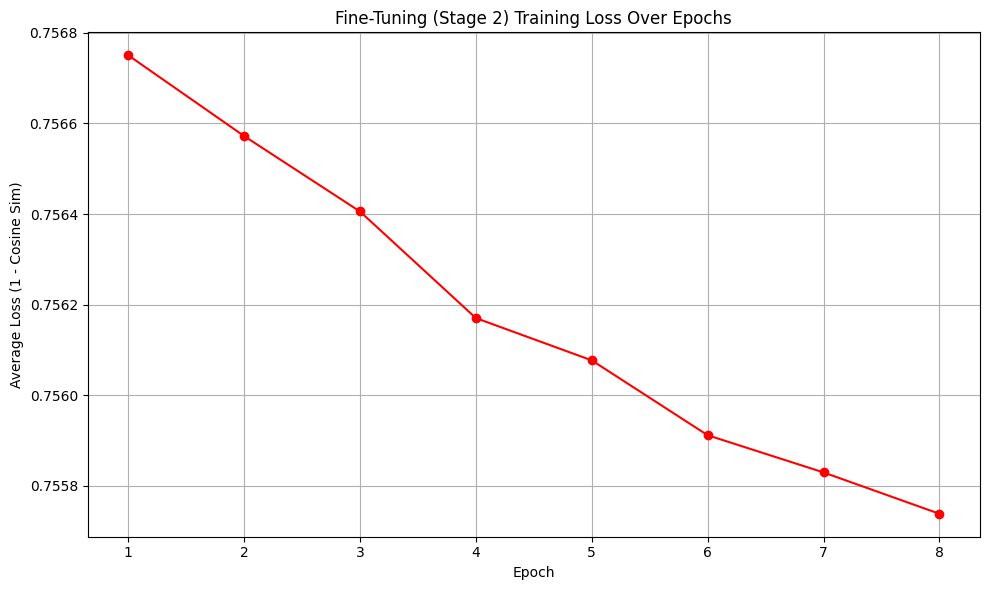

In [ ]:
# ======================================================
# 📊 Plotting Loss Curve for Fine-Tuning (Stage 2)
# ======================================================
import torch
import os
import re # For matching filenames
import matplotlib.pyplot as plt

# --- 1. Configuration ---

# This is the directory where all your checkpoints are saved
CHECKPOINT_DIR = "/content/drive/MyDrive/My_Audio2Img_Checkpoints"

# ⚠️ IMPORTANT: This pattern must match your filenames
# We use regex to extract the epoch number (the \d+)
FT_CHECKPOINT_PATTERN = r"sd_finetune_clip_loss_epoch_(\d+)\.pt"

# ⚠️ This MUST match the key you used in your torch.save() dict
# Based on your code, the key is "loss"
LOSS_KEY = "loss"

print(f"📂 Scanning for Fine-Tuning checkpoints in: {CHECKPOINT_DIR}")
print("⏳ This will be VERY SLOW. Each checkpoint is ~4GB.")
print("   Please be patient, it is not frozen...")

# --- 2. Load Fine-Tuning (Stage 2) Loss Data ---
ft_loss_data = []

try:
    # Get a sorted list of files to process them in order
    all_files = sorted(os.listdir(CHECKPOINT_DIR))

    for f in all_files:
        match = re.search(FT_CHECKPOINT_PATTERN, f)
        if match:
            # Extract epoch number
            epoch = int(match.group(1))

            print(f"  Loading file: {f} (Epoch {epoch})...")

            # Load the checkpoint file
            file_path = os.path.join(CHECKPOINT_DIR, f)
            checkpoint = torch.load(file_path, map_location="cpu")

            if LOSS_KEY in checkpoint:
                ft_loss_data.append((epoch, checkpoint[LOSS_KEY]))
            else:
                print(f"  Warning: Found {f} but key '{LOSS_KEY}' was missing.")

except Exception as e:
    print(f"❌ Error loading Fine-Tuning checkpoints: {e}")

# Sort the data by epoch number (though it should be already)
ft_loss_data.sort(key=lambda x: x[0])
print(f"\n✅ Found {len(ft_loss_data)} Fine-Tuning loss entries.")


# --- 3. Plot the Graph ---
print("\n📊 Generating plot...")
plt.figure(figsize=(10, 6)) # Create a single, larger plot

if ft_loss_data:
    # Unzip the (epoch, loss) tuples
    ft_epochs, ft_losses = zip(*ft_loss_data)
    plt.plot(ft_epochs, ft_losses, marker='o', linestyle='-', color='r')
    plt.title("Fine-Tuning (Stage 2) Training Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss (1 - Cosine Sim)")
    plt.grid(True)
    # Set x-ticks to be integers, e.g., 1, 2, 3...
    if ft_epochs:
        plt.xticks(range(min(ft_epochs), max(ft_epochs) + 1))
else:
    plt.title("Fine-Tuning (Stage 2) - No Data Found")

plt.tight_layout()
plt.show()

# Evaluation

⏳ Loading models for diagnosis...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Fine-tuned weights loaded.

🧪 Testing Prompt: 'A photo of Constant rattling noise and sharp vibrations'
   Audio Embed Mean: -0.0045 | Max: 0.1060
   Generating TEXT ONLY...


/tmp/ipython-input-57609668.py:56: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(device)


  0%|          | 0/30 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


   Generating AUDIO + TEXT...


  0%|          | 0/30 [00:00<?, ?it/s]

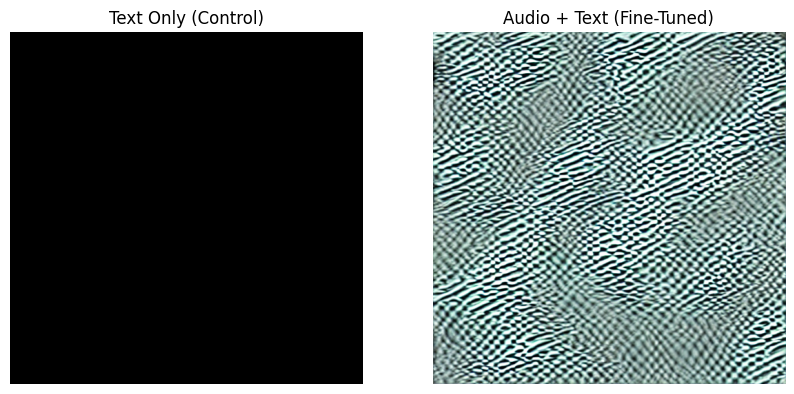

In [ ]:
# ======================================================
# 🩺 Diagnostic: Text-Only vs. Audio+Text
# ======================================================
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor, ClapModel, ClapProcessor
import librosa

# ---- Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/content/drive/MyDrive/My_Audio2Img_Checkpoints/sd_finetune_clip_loss_epoch_8.pt"
EPS = 1e-8

# Define Adapter
class AudioToTextAdapter(nn.Module):
    def __init__(self, input_dim=512, output_dim=512, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x): return self.net(x)

# Load Models
print("⏳ Loading models for diagnosis...")
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
adapter = AudioToTextAdapter(input_dim=512, output_dim=512).to(device)
proj_to_768 = nn.Linear(512, 768).to(device)

# Load Weights
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    pipe.unet.load_state_dict(checkpoint["unet"], strict=False)
    adapter.load_state_dict(checkpoint["adapter"], strict=False)
    proj_to_768.load_state_dict(checkpoint["proj"], strict=False)
    print("✅ Fine-tuned weights loaded.")
else:
    print("❌ Checkpoint not found.")

# ---- Diagnostic Function ----
def test_generation(audio_path, label):
    print(f"\n🧪 Testing Prompt: '{label}'")

    # 1. Prepare Text Embedding
    text_inputs = pipe.tokenizer(label, return_tensors="pt", padding="max_length", truncation=True, max_length=77).to(device)
    text_emb = pipe.text_encoder(**text_inputs).last_hidden_state
    text_emb = F.normalize(text_emb + EPS, dim=-1)

    # 2. Prepare Audio Embedding
    audio, _ = librosa.load(audio_path, sr=48000, mono=True)
    audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(device)
    with torch.no_grad():
        e_audio = F.normalize(clap_model.get_audio_features(**audio_inputs) + EPS, dim=-1)
        e_cond = F.normalize(adapter(e_audio.float()) + EPS, dim=-1)
        e_cond_768 = F.normalize(proj_to_768(e_cond.float()) + EPS, dim=-1)

        # Check for "Exploding" values
        print(f"   Audio Embed Mean: {e_cond_768.mean().item():.4f} | Max: {e_cond_768.max().item():.4f}")

    # 3. Combine
    cond_combined = F.normalize((text_emb + e_cond_768.unsqueeze(1)) / 2 + EPS, dim=-1)

    # 4. Generate Images
    print("   Generating TEXT ONLY...")
    img_text = pipe(prompt_embeds=text_emb, num_inference_steps=30, guidance_scale=7.5).images[0]

    print("   Generating AUDIO + TEXT...")
    img_combined = pipe(prompt_embeds=cond_combined, num_inference_steps=30, guidance_scale=7.5).images[0]

    # Show side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_text)
    ax[0].set_title("Text Only (Control)")
    ax[0].axis("off")

    ax[1].imshow(img_combined)
    ax[1].set_title("Audio + Text (Fine-Tuned)")
    ax[1].axis("off")
    plt.show()

# Run on 1 sample
if len(test_pairs) > 0:
    test_generation(test_pairs[0][0], f"A photo of {test_pairs[0][1]}")

In [ ]:
# ======================================================
# 🎧 Load Test Dataset with REAL Captions (FIXED)
# ======================================================
import os
import csv # Use the CSV module to correctly handle commas in captions

# --- 1. Define Paths ---
TEST_DATA_ROOT = "/content/drive/MyDrive/extracted_audiocaps"
CAPTIONS_FILE = os.path.join(TEST_DATA_ROOT, "captions.txt")
AUDIO_DIR = TEST_DATA_ROOT # Audio files are in the root

# --- 2. Sanity Checks ---
if not os.path.exists(CAPTIONS_FILE):
    raise FileNotFoundError(f"❌ Captions file not found at '{CAPTIONS_FILE}'")
if not os.path.exists(AUDIO_DIR):
    raise FileNotFoundError(f"❌ Audio directory not found at '{AUDIO_DIR}'")

print("✅ Found captions file and audio directory.")

# --- 3. Parse Captions and Build 'test_pairs' ---
test_pairs = []
print(f"⏳ Reading captions from {os.path.basename(CAPTIONS_FILE)}...")

files_found_count = 0
files_missing_count = 0

with open(CAPTIONS_FILE, 'r', encoding='utf-8') as f:

    # The file is TAB-separated (\t)
    reader = csv.reader(f, delimiter='\t')

    # Loop over each row in the captions file
    for row in reader:

        # ⬇️⬇️⬇️ THIS IS THE NEW, SIMPLIFIED LOGIC ⬇️⬇️⬇️

        # Check if the row has at least 2 columns
        if len(row) < 2:
            # print(f"Skipping malformed row: {row}") # Uncomment for debugging
            continue

        # Column 0 is filename, Column 1 is caption
        audio_filename = row[0].strip()
        caption = row[1].strip()

        # ⬆️⬆️⬆️ END OF SIMPLIFIED LOGIC ⬆️⬆️⬆️

        # Construct the full path to the audio file
        full_audio_path = os.path.join(AUDIO_DIR, audio_filename)

        # Only add the pair if the audio file *actually exists*
        if os.path.exists(full_audio_path):
            test_pairs.append((full_audio_path, caption))
            files_found_count += 1
        else:
            files_missing_count += 1

print("\n--- Parsing Debug ---")
print(f"Total lines processed in .txt: {files_found_count + files_missing_count}")
print(f"✅ Audio files found and matched: {files_found_count}")
print(f"❌ Files listed in .txt but NOT found in folder: {files_missing_count}")

if files_missing_count > 0 and files_found_count == 0:
    print("\n❌ CRITICAL ERROR: No audio files were found. It seems the file paths in 'captions.txt' do not match the files in your folder.")
    print("   Please check your file names. Is '0.flac' in the 'extracted_ audiocaps' folder?")

print(f"\n✅ Successfully built 'test_pairs' list with {len(test_pairs)} real captions.")

# Print 5 random samples to check
import random
print("\n--- 5 Random Test Samples ---")
if test_pairs:
    for audio_path, label in random.sample(test_pairs, 5):
        print(f"🎵 {label}: {os.path.basename(audio_path)}")
else:
    print("❌ 'test_pairs' list is empty. Check your paths and file format.")

✅ Dataset loaded. Found 963 test pairs.
🚀 Using device: cuda
⏳ Loading models...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Safety checker disabled (to see raw output).
⏳ Loading weights from sd_finetune_clip_loss_epoch_1.pt...


KeyboardInterrupt: 

✅ Dataset loaded. Found 963 test pairs.
🚀 Using device: cuda
⏳ Loading models...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Safety checker disabled (to see raw output).
✅ Switched to Euler Ancestral (Euler a) Scheduler for smoother images.
⏳ Loading weights from sd_finetune_clip_loss_epoch_8.pt...
✅ Weights loaded successfully!

🎨 Generating 10 images with OPTIMIZED settings...


  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipython-input-207902311.py:111: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(device)


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

 90%|█████████ | 9/10 [00:28<00:03,  3.11s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:31<00:00,  3.11s/it]


--- 📊 Evaluation Results (Epoch 8) ---
Average CLIP Similarity: 0.1915


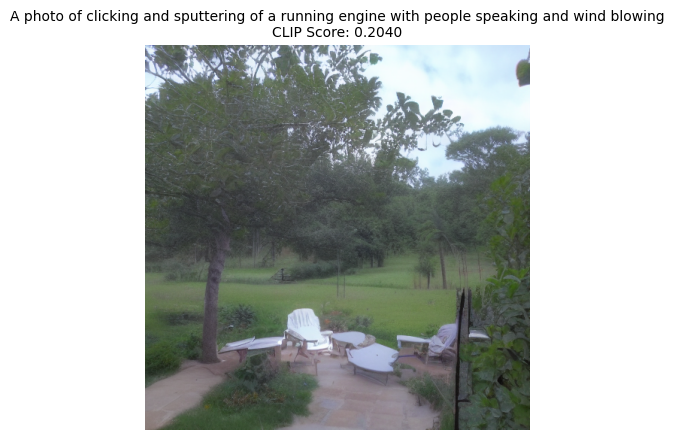

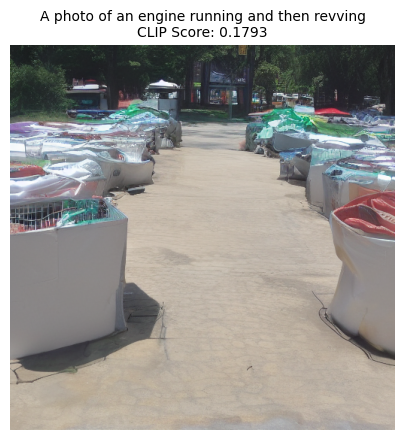

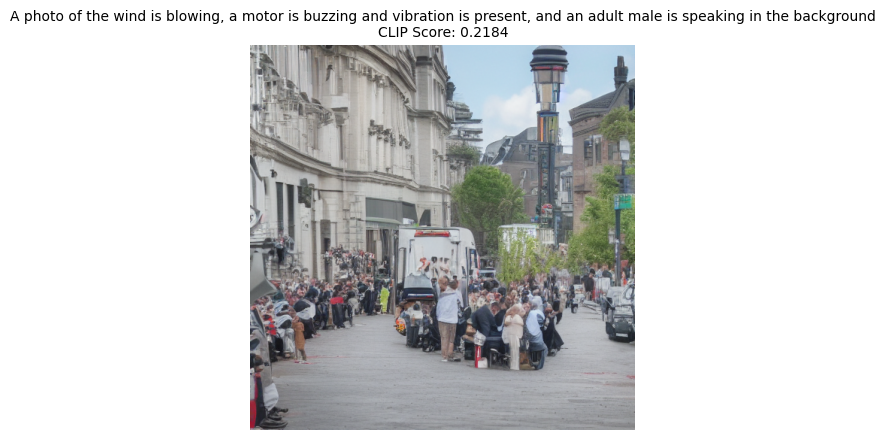

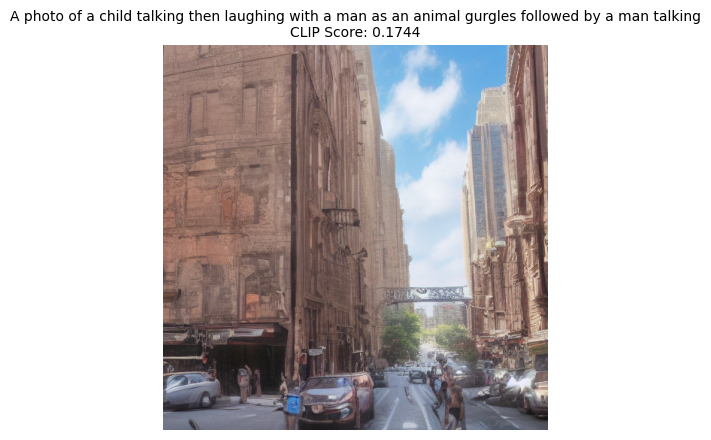

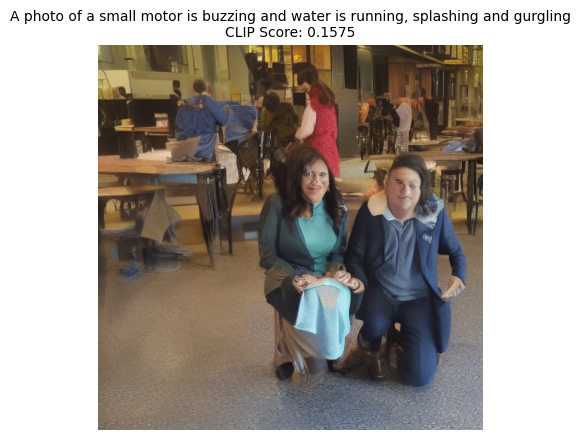

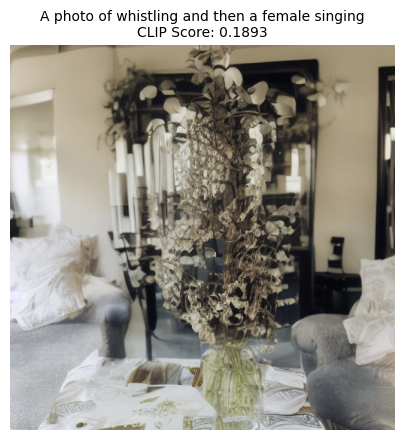

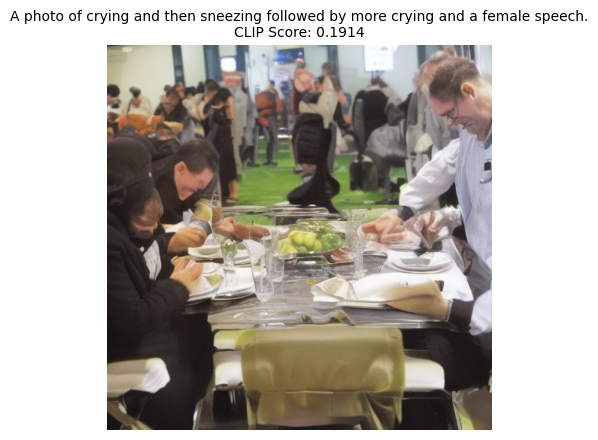

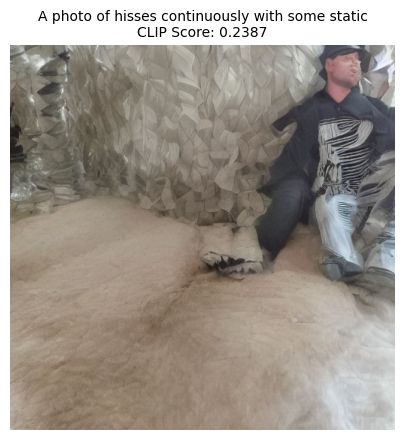

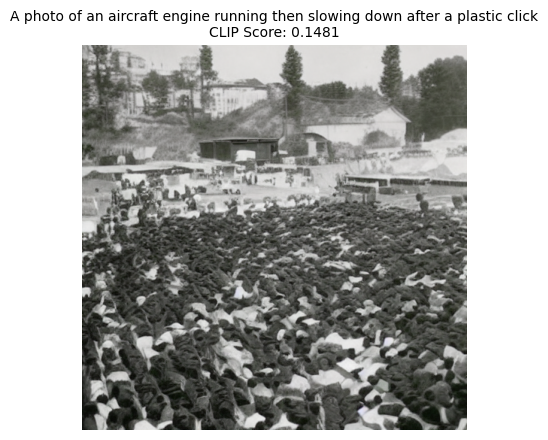

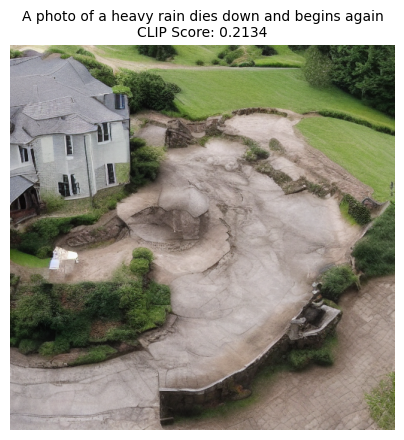

In [ ]:
# ======================================================
# 🖼️ Audio → Image Inference (Optimized + No Safety Filter)
# ======================================================
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import librosa, os
from tqdm import tqdm
from transformers import ClapModel, ClapProcessor, CLIPModel, CLIPProcessor
import random

# ---- 0. Check for Dataset ----
try:
    print(f"✅ Dataset loaded. Found {len(test_pairs)} test pairs.")
except NameError:
    print("❌ ERROR: 'test_pairs' not found. Please run the dataset loading cell above first.")
    test_pairs = []

# ---- 1. Define Model Architecture ----
class AudioToTextAdapter(nn.Module):
    def __init__(self, input_dim=512, output_dim=512, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# ---- 2. Setup Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

# 🎯 TARGET CHECKPOINT
# Note: If Epoch 8 looks like noise, try changing this to epoch_1.pt
CHECKPOINT_PATH = "/content/drive/MyDrive/My_Audio2Img_Checkpoints/sd_finetune_clip_loss_epoch_8.pt"
OUTPUT_DIR = "/content/generated_images_evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- 3. Load Models ----
print("⏳ Loading models...")

# A. Base Pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

# ⬇️⬇️⬇️ NEW: DISABLE SAFETY CHECKER ⬇️⬇️⬇️
def dummy_checker(images, **kwargs):
    return images, [False] * len(images)

pipe.safety_checker = dummy_checker
print("✅ Safety checker disabled (to see raw output).")
# ⬆️⬆️⬆️ END OF NEW BLOCK ⬆️⬆️⬆️

# ⬇️⬇️⬇️ FIX 1: Use Euler Ancestral Scheduler ⬇️⬇️⬇️
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
print("✅ Switched to Euler Ancestral (Euler a) Scheduler for smoother images.")

# B. Conditioners & Evaluators
clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
clip_eval_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_eval_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# C. Trainable Components
adapter = AudioToTextAdapter(input_dim=512, output_dim=512).to(device)
proj_to_768 = nn.Linear(512, 768).to(device)

# D. Load Fine-Tuned Weights
if os.path.exists(CHECKPOINT_PATH):
    print(f"⏳ Loading weights from {os.path.basename(CHECKPOINT_PATH)}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    try:
        pipe.unet.load_state_dict(checkpoint["unet"])
        adapter.load_state_dict(checkpoint["adapter"])
        proj_to_768.load_state_dict(checkpoint["proj"])
        print("✅ Weights loaded successfully!")
    except RuntimeError as e:
        print(f"⚠️ Error loading weights: {e}")
        print("Trying 'strict=False' loading...")
        pipe.unet.load_state_dict(checkpoint["unet"], strict=False)
        adapter.load_state_dict(checkpoint["adapter"], strict=False)
        proj_to_768.load_state_dict(checkpoint["proj"], strict=False)
        print("✅ Weights loaded with strict=False.")
else:
    print(f"❌ ERROR: Checkpoint not found at {CHECKPOINT_PATH}")

# Set to Eval Mode
pipe.unet.eval()
adapter.eval()
proj_to_768.eval()
clap_model.eval()

# ---- 4. Inference Logic ----
EPS = 1e-8

# ⬇️⬇️⬇️ FIX 2: Stronger Negative Prompt ⬇️⬇️⬇️
NEGATIVE_PROMPT = "glitch, metallic, broken, low quality, blurry, distorted, noise, grain, ugly, deformation, watermark, text, bad anatomy, abstract, surreal"

def generate_image_robust(audio_path, label, pipe, adapter, proj, clap_model, clap_processor):
    try:
        # 1. Audio Processing
        audio, _ = librosa.load(audio_path, sr=48000, mono=True)
        audio_inputs = clap_processor(audios=audio, return_tensors="pt", sampling_rate=48000).to(device)

        with torch.no_grad():
            e_audio = F.normalize(clap_model.get_audio_features(**audio_inputs) + EPS, dim=-1)
            e_cond = F.normalize(adapter(e_audio.to(next(adapter.parameters()).dtype)) + EPS, dim=-1)
            e_cond_768 = F.normalize(proj(e_cond.to(proj.weight.dtype)) + EPS, dim=-1)

            # 2. Positive Text Processing
            prompt = f"A photo of {label.lower()}"
            text_inputs = pipe.tokenizer(prompt, return_tensors="pt", padding="max_length", truncation=True, max_length=pipe.tokenizer.model_max_length).to(device)
            text_emb = pipe.text_encoder(**text_inputs).last_hidden_state
            text_emb = F.normalize(text_emb + EPS, dim=-1)

            # 3. Combine (Positive Conditioning)
            cond = F.normalize((text_emb + e_cond_768.unsqueeze(1)) / 2 + EPS, dim=-1)

            # Negative Embeddings
            neg_inputs = pipe.tokenizer(NEGATIVE_PROMPT, return_tensors="pt", padding="max_length", truncation=True, max_length=pipe.tokenizer.model_max_length).to(device)
            neg_emb = pipe.text_encoder(**neg_inputs).last_hidden_state
            neg_emb = F.normalize(neg_emb + EPS, dim=-1)

            # 4. Generate
            image = pipe(
                prompt_embeds=cond.to(pipe.unet.dtype),
                negative_prompt_embeds=neg_emb.to(pipe.unet.dtype),
                prompt=None,
                num_inference_steps=50,
                guidance_scale=3.5,     # ⬇️⬇️⬇️ FIX 3: Lowered guidance
                height=512, width=512
            ).images[0]

            return image, prompt

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None, None

# ---- 5. Evaluation Loop ----
NUM_SAMPLES = 10
if len(test_pairs) > 0:
    eval_samples = random.sample(test_pairs, min(len(test_pairs), NUM_SAMPLES))
    print(f"\n🎨 Generating {len(eval_samples)} images with OPTIMIZED settings...")

    results = []

    for audio_path, label in tqdm(eval_samples):
        image, prompt = generate_image_robust(audio_path, label, pipe, adapter, proj_to_768, clap_model, clap_processor)

        if image:
            with torch.no_grad():
                inputs = clip_eval_processor(text=[prompt], images=image, return_tensors="pt", padding=True).to(device)
                outputs = clip_eval_model(**inputs)
                img_embeds = outputs.image_embeds
                text_embeds = outputs.text_embeds
                score = F.cosine_similarity(img_embeds, text_embeds).item()

            results.append((image, prompt, score))

    # ---- 6. Display Results ----
    print("\n--- 📊 Evaluation Results (Epoch 8) ---")
    if results:
        avg_score = sum(r[2] for r in results) / len(results)
        print(f"Average CLIP Similarity: {avg_score:.4f}")

        for img, p, s in results:
            plt.figure(figsize=(5, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{p}\nCLIP Score: {s:.4f}", fontsize=10)
            plt.show()
    else:
        print("No images generated.")
else:
    print("❌ No test pairs found.")

In [ ]:
# # ======================================================
# # 🎨 Stable Diffusion Fine-Tuning (FIXED & STABILIZED)
# # ======================================================
# from diffusers import StableDiffusionPipeline, DDPMScheduler
# import torch, torch.nn as nn, torch.nn.functional as F
# from tqdm import tqdm
# import librosa, os, numpy as np, math
# import matplotlib.pyplot as plt
# from PIL import Image
# from torchvision import transforms
# from transformers import CLIPModel, CLIPProcessor, ClapModel, ClapProcessor
# from transformers import get_scheduler

# # --- 0️⃣ CRITICAL SETUP (Fixes NameErrors) ---
# class AudioToTextAdapter(nn.Module):
#     def __init__(self, input_dim=512, output_dim=512, hidden_dim=1024):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.GELU(),
#             nn.Linear(hidden_dim, output_dim)
#         )
#     def forward(self, x):
#         return self.net(x)

# # ---- Device setup ----
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"🚀 Using device: {device}")

# # --- 🎯 Persistent Checkpoint Setup ---
# PERSISTENT_CHECKPOINT_DIR = "/content/drive/MyDrive/My_Audio2Img_Checkpoints"
# os.makedirs(PERSISTENT_CHECKPOINT_DIR, exist_ok=True)

# # ---- 1️⃣ Load ALL required models ----
# pipe = StableDiffusionPipeline.from_pretrained(
#     "runwayml/stable-diffusion-v1-5",
#     torch_dtype=torch.float16
# ).to(device)

# unet = pipe.unet
# text_encoder = pipe.text_encoder
# tokenizer = pipe.tokenizer
# vae = pipe.vae
# scheduler = DDPMScheduler(num_train_timesteps=1000)

# clip_loss_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
# clip_loss_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
# adapter = AudioToTextAdapter(input_dim=512, output_dim=512).to(device)
# clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
# clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

# # --- 2️⃣ Freeze Models ---
# clip_loss_model.requires_grad_(False)
# text_encoder.requires_grad_(False)
# vae.requires_grad_(False)
# clap_model.requires_grad_(False)

# unet.enable_gradient_checkpointing()
# adapter.train() # Make sure adapter is in train mode
# proj_to_768 = nn.Linear(512, 768).to(device) # This layer handles the 512 -> 768 upscaling
# proj_to_768.train() # Set to train mode

# # --- 3️⃣ Load Best Adapter (from Stage 1) ---
# BEST_ADAPTER_CHECKPOINT = os.path.join(PERSISTENT_CHECKPOINT_DIR, "adapter_alignment_checkpoint_epoch_20.pt")
# try:
#     adapter_checkpoint = torch.load(BEST_ADAPTER_CHECKPOINT, map_location=device)
#     adapter.load_state_dict(adapter_checkpoint["adapter_state_dict"])
#     print(f"✅ Loaded best adapter weights from {os.path.basename(BEST_ADAPTER_CHECKPOINT)}")
# except Exception as e:
#     print(f"❌ Could not load adapter weights: {e}. Training with current (possibly random) adapter.")

# # ⬇️⬇️⬇️ THIS IS THE MODIFIED PART ⬇️⬇️⬇️
# # --- 4️⃣ Optimizer (NEW: *MORE* Stable Differential LRs) ---
# # We are lowering the LRs even more to prevent explosion.
# optimizer = torch.optim.AdamW(
#     [
#         # Group 1: Your new, small layers (LR lowered 10x)
#         {
#             "params": list(adapter.parameters()) + list(proj_to_768.parameters()),
#             "lr": 1e-6  # <<< WAS 1e-5. This is the most likely culprit.
#         },
#         # Group 2: The pre-trained UNet (LR lowered slightly)
#         {
#             "params": unet.parameters(),
#             "lr": 5e-9  # <<< WAS 1e-8. Extra safe.
#         },
#     ],
#     weight_decay=1e-3
# )
# print("✅ Optimizer created with *MORE STABLE* Differential Learning Rates.")
# # ⬆️⬆️⬆️ END OF MODIFIED PART ⬆️⬆️⬆️

# # --- 5️⃣ Helpers ---
# def safe_load_audio(path, sr=48000):
#     try:
#         audio, _ = librosa.load(path, sr=sr, mono=True)
#         if not np.any(audio): raise ValueError("Empty waveform")
#         return audio
#     except Exception: return None

# def nan_guard(x):
#     return torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

# # --- 5.5 CLIP Preprocessing Constants ---
# CLIP_IMAGE_SIZE = clip_loss_processor.image_processor.crop_size["height"]
# CLIP_MEAN = torch.tensor(clip_loss_processor.image_processor.image_mean, device=device).view(1, -1, 1, 1)
# CLIP_STD = torch.tensor(clip_loss_processor.image_processor.image_std, device=device).view(1, -1, 1, 1)

# # --- 6️⃣ Training Setup ---
# EPOCHS =  # We can try 7 again
# subset = pairs # Full 'pairs' list

# GRAD_ACCUMULATION_STEPS = 8
# NUM_TRAINING_STEPS = (len(subset) // GRAD_ACCUMULATION_STEPS) * EPOCHS
# NUM_WARMUP_STEPS = 500 # 500 steps is still fine

# lr_scheduler = get_scheduler(
#     "linear",
#     optimizer=optimizer,
#     num_warmup_steps=NUM_WARMUP_STEPS,
#     num_training_steps=NUM_TRAINING_STEPS,
# )
# print(f"✅ Using Gradient Accumulation (steps={GRAD_ACCUMULATION_STEPS})")
# print(f"✅ Using LR Scheduler (warmup={NUM_WARMUP_STEPS}, total={NUM_TRAINING_STEPS})")

# loss_log = []
# print(f"🧩 Training on {len(subset)} samples × {EPOCHS} epochs (CLIP Loss)")

# # ---- 7️⃣ Training Loop (FIXED & STABILIZED) ----
# global_step = 0
# for epoch in range(EPOCHS):
#     total_loss = 0.0

#     for step, (path, label) in enumerate(tqdm(subset, desc=f"🎧 Epoch {epoch+1}", ncols=100)):

#         # --- 1. Load Audio ---
#         audio = safe_load_audio(path)
#         if audio is None: continue

#         # --- 2. Get Audio/Text Conditioning ---
#         prompt = f"A photo of {label.lower()}"
#         with torch.no_grad():
#             audio_inputs = clap_processor(audio=audio, return_tensors="pt", sampling_rate=48000).to(device)
#             e_audio = F.normalize(clap_model.get_audio_features(**audio_inputs), dim=-1)

#         e_cond = F.normalize(adapter(e_audio.to(next(adapter.parameters()).dtype)), dim=-1)
#         e_cond_768 = F.normalize(proj_to_768(e_cond.to(proj_to_768.weight.dtype)), dim=-1)

#         text_inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True).to(device)
#         with torch.no_grad():
#             text_emb = text_encoder(**text_inputs).last_hidden_state
#             text_emb = F.normalize(text_emb, dim=-1)

#         cond = F.normalize((text_emb + e_cond_768.unsqueeze(1)) / 2, dim=-1).to(unet.dtype)

#         # --- 3. Get Target Text Embedding (for Loss) ---
#         with torch.no_grad():
#             clip_text_inputs = clip_loss_processor(text=[prompt], return_tensors="pt", padding=True).to(device)
#             e_text_target = F.normalize(clip_loss_model.get_text_features(**clip_text_inputs), dim=-1)

#         # --- 4. Latent Diffusion (One-Step Prediction) ---
#         with torch.no_grad():
#             latents = torch.randn((1, unet.config.in_channels, 64, 64), device=device, dtype=unet.dtype)
#             noise = torch.randn_like(latents)
#             t = torch.randint(0, scheduler.config.num_train_timesteps, (1,), device=device).long()
#             noisy_latents = scheduler.add_noise(latents, noise, t)

#         # --- 5. Forward + CLIP Loss ---
#         with torch.amp.autocast("cuda"):
#             noise_pred = unet(noisy_latents, t, encoder_hidden_states=cond).sample
#             pred_latents = scheduler.step(noise_pred, t, noisy_latents).pred_original_sample
#             pred_image = vae.decode(pred_latents.float() / vae.config.scaling_factor).sample

#             pred_image_normalized = ((pred_image + 1) / 2.0).clamp(0, 1)
#             clip_image = F.interpolate(
#                 pred_image_normalized.float(),
#                 size=(CLIP_IMAGE_SIZE, CLIP_IMAGE_SIZE),
#                 mode='bicubic',
#                 align_corners=False
#             )
#             clip_input_tensor = (clip_image - CLIP_MEAN.to(clip_image.dtype)) / CLIP_STD.to(clip_image.dtype)
#             e_image_pred = F.normalize(clip_loss_model.get_image_features(pixel_values=clip_input_tensor.half()), dim=-1)

#             loss = 1 - F.cosine_similarity(e_image_pred, e_text_target.half()).mean()
#             loss = nan_guard(loss)

#             loss = loss / GRAD_ACCUMULATION_STEPS

#         if torch.isnan(loss) or torch.isinf(loss):
#             continue

#         # --- 6. Backpropagation ---
#         loss.backward()

#         if (step + 1) % GRAD_ACCUMULATION_STEPS == 0:
#             torch.nn.utils.clip_grad_norm_(
#                 list(adapter.parameters()) + list(proj_to_768.parameters()) + list(unet.parameters()),
#                 1.0
#             )
#             optimizer.step()
#             lr_scheduler.step()
#             optimizer.zero_grad(set_to_none=True)
#             global_step += 1

#         total_loss += loss.item() * GRAD_ACCUMULATION_STEPS

#         if global_step > 0 and global_step % 100 == 0:
#             adapter_lr = optimizer.param_groups[0]['lr']
#             unet_lr = optimizer.param_groups[1]['lr']
#             print(f"[Step {global_step}] Loss: {loss.item() * GRAD_ACCUMULATION_STEPS:.6f} | Adapter LR: {adapter_lr:.2e} | UNet LR: {unet_lr:.2e}")

#     avg_loss = total_loss / max(1, len(subset))
#     loss_log.append(avg_loss)
#     print(f"🧠 Epoch {epoch+1}/{EPOCHS} | Avg CLIP Loss: {avg_loss:.6f}")

#     # 💾 Save checkpoint
#     checkpoint_name = os.path.join(PERSISTENT_CHECKPOINT_DIR, f"sd_finetune_clip_loss_epoch_{epoch+1}.pt")
#     torch.save({
#         "epoch": epoch + 1,
#         "unet": unet.state_dict(),
#         "adapter": adapter.state_dict(),
#         "proj": proj_to_768.state_dict(),
#         "optimizer": optimizer.state_dict(),
#         "loss": avg_loss
#     }, checkpoint_name)
#     print(f"✅ Saved checkpoint to Drive: {checkpoint_name}")

# # ---- 📈 Plot loss curve ----
# plt.figure(figsize=(6,4))
# plt.plot(range(1, len(loss_log)+1), loss_log, marker="o")
# plt.title("Training Loss over Epochs (CLIP Similarity Loss)")
# plt.xlabel("Epoch")
# plt.ylabel("Avg Loss (1 - Cosine Sim)")
# plt.grid(True)
# plt.show()

# print("✅ Fine-tuning complete — model checkpoints saved.")

🚀 Using device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Loaded best adapter weights from adapter_alignment_checkpoint_epoch_20.pt
✅ Optimizer created with *MORE STABLE* Differential Learning Rates.
✅ Using Gradient Accumulation (steps=8)
✅ Using LR Scheduler (warmup=500, total=3)
🧩 Training on 10 samples × 3 epochs (CLIP Loss)


🎧 Epoch 1:   0%|                                                            | 0/10 [00:00<?, ?it/s]/tmp/ipython-input-2991434777.py:96: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
🎧 Epoch 1: 100%|█████████████████████████████████████████████████| 10/10 [00:00<00:00, 6601.05it/s]

🧠 Epoch 1/3 | Avg CLIP Loss: 0.000000


✅ Saved checkpoint to Drive: /content/drive/MyDrive/My_Audio2Img_Checkpoints/sd_finetune_clip_loss_epoch_1.pt


🎧 Epoch 2: 100%|█████████████████████████████████████████████████| 10/10 [00:00<00:00, 8174.44it/s]

🧠 Epoch 2/3 | Avg CLIP Loss: 0.000000


KeyboardInterrupt: 